# **Implementación de los casos de 3 Qubits**

In [49]:
%load_ext autoreload
%autoreload 2

from modules import schnorr_lattice as sl
from modules import qaoa as q
from modules import utils

import numpy as np
import matplotlib.pyplot as plt
from qiskit.visualization import plot_histogram


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [50]:
seed = 42

In [51]:
N3 = 1961

In [52]:
threeQubit = sl.schnorrCVP(N3, 1.5, 1, seed)

El numero de bits de N = 1961 es m = 11
La dimension del reticulo que vamos a tratar es n = 3
La cota smooth que vamos a tomar: 18


## **1. Algoritmo de Schnorr**

In [53]:
cvpInstance = threeQubit.generate_cvp(10)

B = 
[ 1 0 0 22 ]
[ 0 1 0 35 ]
[ 0 0 2 51 ]
t = 
(0, 0, 0, 240)


In [54]:
D3 = threeQubit.lll_reduced(cvpInstance.B, delta = 0.75)
print(f'D3 = \n{D3}')

D3 = 
[  1 -2 2  3 ]
[ -4  1 2 -2 ]
[ -3  2 0  4 ]


In [55]:
cvpResult = threeQubit.babai_algorithm(cvpInstance, delta = 0.75)
print(f'D3 = \n{cvpResult.D}\n')
print(f'b_op3 = \n{cvpResult.b_op}\n')
print(f'res_vector3 = \n{cvpResult.res_vector}\n')
print(f'step_sign3 = \n{cvpResult.step_sign}\n')
print(f'w3 = \n{cvpResult.weight}\n')

D3 = 
[  1 -2 2  3 ]
[ -4  1 2 -2 ]
[ -3  2 0  4 ]

b_op3 = 
[  0   4   4 242]

res_vector3 = 
[ 0 -4 -4 -2]

step_sign3 = 
[-1 -1 -1]

w3 = 
(22, -20, 34)



## **2. Algoritmo QAOA**

In [56]:
qubo3 = q.define_qubo(cvpResult.D, cvpResult.res_vector, cvpResult.step_sign, threeQubit.get_n())

print(qubo3.prettyprint())

Problem name: quboProblem

Minimize
  18*z_0^2 - 16*z_0*z_1 + 10*z_0*z_2 + 25*z_1^2 + 12*z_1*z_2 + 29*z_2^2 - 12*z_0
  - 16*z_1 - 32*z_2 + 36

Subject to
  No constraints

  Binary variables (3)
    z_0 z_1 z_2



In [57]:
Hc3, offset3 = q.define_hamiltonian(qubo3)

print("Offset = {}\n".format(offset3))
print("Hamiltonian = {}".format(Hc3))

Offset = 43.5

Hamiltonian = SparsePauliOp(['IZI', 'ZII', 'IIZ', 'IZZ', 'ZIZ', 'ZZI'],
              coeffs=[-3.5+0.j, -4. +0.j, -1.5+0.j, -4. +0.j,  2.5+0.j,  3. +0.j])


In [58]:
formatted_h = " + ".join([f"{c.real:.3f}{s}" for s, c in Hc3.label_iter()])
print(formatted_h)

-3.500IZI + -4.000ZII + -1.500IIZ + -4.000IZZ + 2.500ZIZ + 3.000ZZI


In [59]:
circuit3 = q.construct_circuit(Hc3, reps = 1)
print(circuit3)

     ┌───┐┌───────────────┐                             ┌────────────┐»
q_0: ┤ H ├┤ Rz((-3)*γ[0]) ├─■───────────────■───────────┤ Rx(2*β[0]) ├»
     ├───┤├───────────────┤ │ZZ((-8)*γ[0])  │           └────────────┘»
q_1: ┤ H ├┤ Rz((-7)*γ[0]) ├─■───────────────┼────────────■────────────»
     ├───┤├───────────────┤                 │ZZ(5*γ[0])  │ZZ(6*γ[0])  »
q_2: ┤ H ├┤ Rz((-8)*γ[0]) ├─────────────────■────────────■────────────»
     └───┘└───────────────┘                                           »
«                   
«q_0: ──────────────
«     ┌────────────┐
«q_1: ┤ Rx(2*β[0]) ├
«     ├────────────┤
«q_2: ┤ Rx(2*β[0]) ├
«     └────────────┘


In [60]:
x0 = np.asarray([0.0]*circuit3.num_parameters)

monitor, optParameters3 = q.qaoa_algorithm(circuit3, Hc3, x0)

In [61]:
print(optParameters3)

{'β[0]': np.float64(-0.5034916687001878), 'γ[0]': np.float64(0.10372812008473253)}


In [62]:
print(f'Total iteraciones = {monitor.iteration}')
print(f'Evolucion de evaluaciones = {monitor.evaluation}')
print(f'Evolucion de parametros = {monitor.parameters}')

Total iteraciones = 59
Evolucion de evaluaciones = [np.float64(-6.974953359879105e-05), np.float64(-6.974953359879105e-05), np.float64(-0.0004184881190862494), np.float64(-0.001069394512198299), np.float64(-0.0040006540585020844), np.float64(-0.010550565092599988), np.float64(-0.03366236662722804), np.float64(-0.09112627233736295), np.float64(-0.26899575193249403), np.float64(-0.7144747620069518), np.float64(-1.8321693203996772), np.float64(-3.4992523592889837), np.float64(-3.8347914119365143), np.float64(-3.8347914119365143), np.float64(-3.8347914119365143), np.float64(-3.8347914119365143), np.float64(-3.8347914119365143), np.float64(-3.8347914119365143), np.float64(-3.8347914119365143), np.float64(-3.858271930511342), np.float64(-3.858271930511342), np.float64(-3.8912908708655696), np.float64(-3.911208274929298), np.float64(-4.0004892476480975), np.float64(-4.0004892476480975), np.float64(-4.146769903324421), np.float64(-4.265180790177032), np.float64(-4.6102452829885365), np.float64

In [63]:
ncircuit3 = q.circ_asign_params(circuit3, optParameters3)
print(ncircuit3)

     ┌───┐┌──────────────┐                             ┌────────────┐»
q_0: ┤ H ├┤ Rz(-0.31118) ├─■──────────────■────────────┤ Rx(-1.007) ├»
     ├───┤├─────────────┬┘ │ZZ(-0.82982)  │            └────────────┘»
q_1: ┤ H ├┤ Rz(-0.7261) ├──■──────────────┼─────────────■────────────»
     ├───┤├─────────────┴┐                │ZZ(0.51864)  │ZZ(0.62237) »
q_2: ┤ H ├┤ Rz(-0.82982) ├────────────────■─────────────■────────────»
     └───┘└──────────────┘                                           »
«                   
«q_0: ──────────────
«     ┌────────────┐
«q_1: ┤ Rx(-1.007) ├
«     ├────────────┤
«q_2: ┤ Rx(-1.007) ├
«     └────────────┘


In [64]:
results3 = q.sample_from_parameters(circuit3, list(optParameters3.values()), shots = 10_000)
print(len(results3))
for bitstring, count in results3.items():
    print(f"Bistring: {bitstring} -> Counts: {count}")

8
Bistring: 011 -> Counts: 3080
Bistring: 000 -> Counts: 2824
Bistring: 100 -> Counts: 2715
Bistring: 001 -> Counts: 984
Bistring: 010 -> Counts: 258
Bistring: 110 -> Counts: 53
Bistring: 111 -> Counts: 52
Bistring: 101 -> Counts: 34


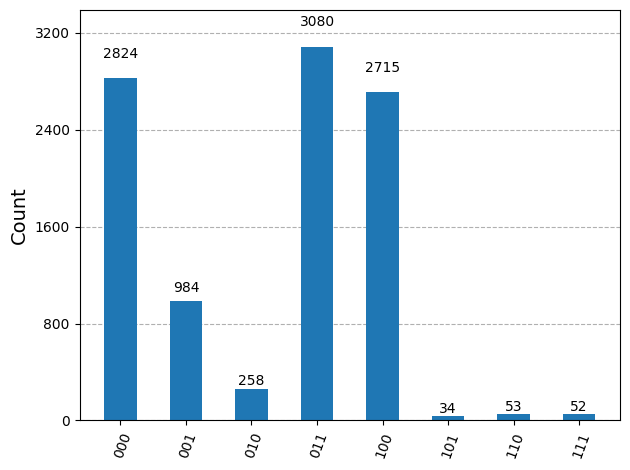

In [65]:
fig = plot_histogram(results3)
fig.savefig("figures/3QubitCase_histograma.png", dpi = 150, bbox_inches = "tight")
fig

## **3. Obtención de SR-Pairs**

In [66]:
nD3 = sl.integer_to_matrix(cvpResult.D)
print(nD3)

[[ 1 -2  2  3]
 [-4  1  2 -2]
 [-3  2  0  4]]


In [67]:
vnew3 = sl.bitstring2latticeVectors(nD3, results3.keys(), cvpResult.step_sign, cvpResult.b_op)
print(vnew3)

[[  3   5   0 241]
 [  0   4   4 242]
 [  3   2   4 238]
 [ -1   6   2 239]
 [  4   3   2 244]
 [  7   1   2 240]
 [  6   3   0 237]
 [  2   4   2 235]]


In [68]:
distances3 = utils.get_distances(vnew3, cvpInstance.t)
for dist in distances3:
    print(np.linalg.norm(dist))

5.916079783099616
6.0
5.744562646538029
6.48074069840786
6.708203932499369
7.3484692283495345
7.3484692283495345
7.0


In [69]:
nB3 = sl.integer_to_matrix(cvpInstance.B)
print(nB3)

[[ 1  0  0 22]
 [ 0  1  0 35]
 [ 0  0  2 51]]


In [70]:
uv_pairs3 = sl.vectors2uv_pairs(nB3, vnew3, threeQubit.get_n())
print(uv_pairs3)

[[1944 1]
 [2025 1]
 [1800 1]
 [3645 2]
 [2160 1]
 [1920 1]
 [1728 1]
 [1620 1]]


In [71]:
sr_pairs3 = sl.uv_pairs2sr_pairs(uv_pairs3, threeQubit)
print(sr_pairs3)

[((1944, 1), -17), ((2025, 1), 64), ((1800, 1), -161), ((1920, 1), -41), ((1620, 1), -341)]


In [72]:
probs3 = utils.get_probs(results3.values(), shots = 10_000)

In [73]:
utils.prettyprint(vnew3, distances3, probs3, cvpResult.b_op, cvpResult.res_vector)

Vector más corto por algoritmo de Babai: 
b_op = [  0   4   4 242]

El vector residual 
t - b_op = [ 0 -4 -4 -2]

La distancia |t - b_op| = 6.000

0: Prob = 0.30800
	vnew = [  3   5   0 241] con distancia: 5.916
1: Prob = 0.28240
	vnew = [  0   4   4 242] con distancia: 6.000
2: Prob = 0.27150
	vnew = [  3   2   4 238] con distancia: 5.745
3: Prob = 0.09840
	vnew = [ -1   6   2 239] con distancia: 6.481
4: Prob = 0.02580
	vnew = [  4   3   2 244] con distancia: 6.708
5: Prob = 0.00530
	vnew = [  7   1   2 240] con distancia: 7.348
6: Prob = 0.00520
	vnew = [  6   3   0 237] con distancia: 7.348
7: Prob = 0.00340
	vnew = [  2   4   2 235] con distancia: 7.000


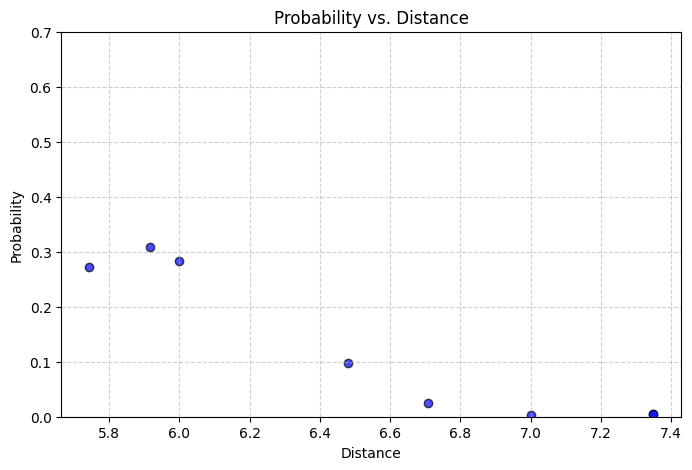

In [74]:
plt.figure(figsize=(8, 5))

# Creating the scatter plot
plt.scatter(distances3, probs3, color='blue', edgecolors='black', alpha=0.7)

# Adding labels and title
plt.xlabel('Distance')
plt.ylabel('Probability')
plt.title('Probability vs. Distance')

# Setting y-axis limit since you mentioned probs are <= 0.2
plt.ylim(0, 0.70) 

plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig("figures/3QubitCase_ProbsDistances.png", dpi=150, bbox_inches="tight")
plt.show()

## **4. Landscape del QAOA**

In [75]:
grid = 300

betha_grid = np.linspace(0, np.pi, grid)
gamma_grid = np.linspace(0, 2*np.pi, grid)

B, G = np.meshgrid(betha_grid, gamma_grid)

param_vals = np.column_stack([B.ravel(), G.ravel()])

In [76]:
evals = q.evaluate_params(circuit3, Hc3, param_vals)

Z = evals.reshape(grid, grid)

In [77]:
#Normalizar entre [-1, 1]
zmin, zmax = Z.min(), Z.max()
z_norm = 2*(Z - zmin)/(zmax - zmin) - 1

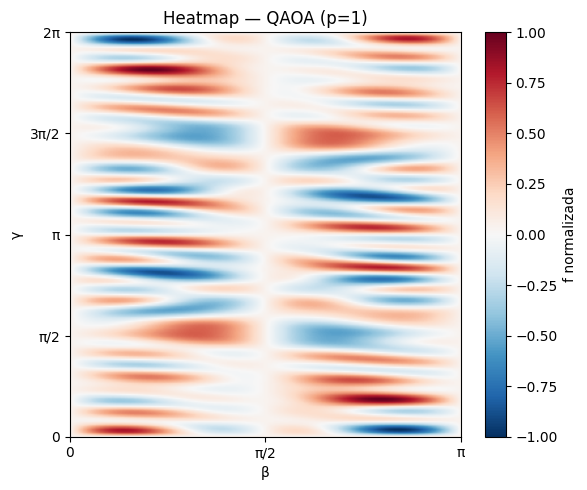

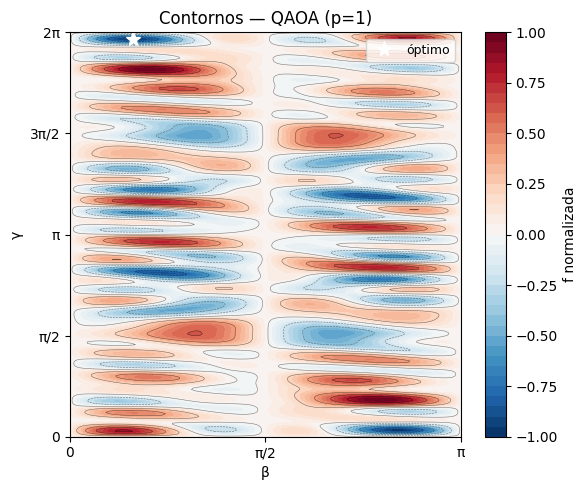

In [78]:
ticks_b = [0, np.pi/2, np.pi]
ticks_g = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]

lbls_b = ["0", "π/2", "π"]
lbls_g = ["0", "π/2", "π", "3π/2", "2π"]

def _format_ax(ax):
    ax.set_xticks(ticks_b); ax.set_xticklabels(lbls_b)
    ax.set_yticks(ticks_g); ax.set_yticklabels(lbls_g)
    ax.set_xlabel("β"); ax.set_ylabel("γ")

# — Figura 1: heatmap ───────────────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(6, 5))
im = ax1.imshow(
    z_norm, origin="lower", aspect="auto",
    extent=[0, np.pi, 0, 2*np.pi],
    cmap="RdBu_r", vmin=-1, vmax=1
)
fig1.colorbar(im, ax=ax1, label="f normalizada")
_format_ax(ax1)
ax1.set_title(f"Heatmap — QAOA (p={1})")
fig1.tight_layout()
fig1.savefig("figures/3QubitCase_heatmap.png", dpi=150)

# — Figura 2: contornos ─────────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(6, 5))
cf = ax2.contourf(B, G, z_norm, levels=40, cmap="RdBu_r", vmin=-1, vmax=1)
ax2.contour(B, G, z_norm, levels=10, colors="k", linewidths=0.4, alpha=0.5)

idx = np.unravel_index(z_norm.argmin(), z_norm.shape)
ax2.plot(B[idx], G[idx], "w*", ms=11, label="óptimo")
ax2.legend(fontsize=9)

fig2.colorbar(cf, ax=ax2, label="f normalizada")
_format_ax(ax2)
ax2.set_title(f"Contornos — QAOA (p={1})")
fig2.tight_layout()
fig2.savefig("figures/3QubitCase_contornos.png", dpi=150)

plt.show()